In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

N = 4 shots = 2000
N = 9 shots = 2000
N = 16 shots = 2000
N = 25 shots = 2000
N = 36 shots = 2000
N = 49 shots = 2000
N = 64 shots = 2000
N = 81 shots = 2000


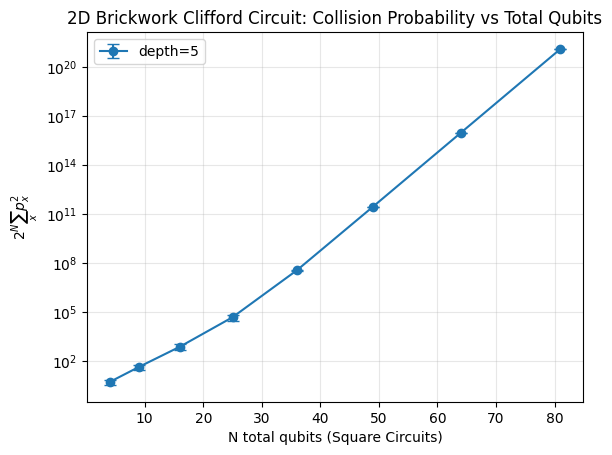

In [ ]:
def random_clifford_t_block(qc, q1, q2, add_t, p_t=0.2):
    for q in [q1, q2]:
        r = np.random.randint(4)
        if r == 0:
            qc.h(q)
        elif r == 1:
            qc.s(q)
        elif r == 2:
            qc.h(q)
            qc.s(q)

    if np.random.rand() < 0.5:
        qc.cx(q1, q2)
    else:
        qc.cx(q2, q1)

    if add_t:
        if np.random.rand() < p_t:
            qc.t(q1)
        if np.random.rand() < p_t:
            qc.t(q2)

def build_circuit_2d(Lx, Ly, d, add_t, p_t=0.2):
    N = Lx * Ly
    qc = QuantumCircuit(N, N//2)

    def idx(x, y):
        return y * Lx + x

    for layer in range(d):
        direction = layer % 2 # 0 = horizontal bonds, 1 = vertical bonds
        offset = (layer // 2) % 2 # brickwork stagger within each direction

        gates_added = False
        if direction == 0:
            for y in range(Ly):
                for x in range(offset, Lx - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x + 1, y), add_t=add_t, p_t=p_t)
                    gates_added = True
        else:
            for x in range(Lx):
                for y in range(offset, Ly - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x, y + 1), add_t=add_t, p_t=p_t)
                    gates_added = True

        if gates_added:
            qc.barrier()
    
    qc.measure(range(N//2), range(N//2))
    return qc

def collision_prob(counts, shots):
    probs = np.array(list(counts.values())) / shots
    return np.sum(probs**2)


# square lattices
L_values = list(range(2, 10))
depth = [5]
samples_per_n = 10
add_t = True

sim = AerSimulator(
    method="matrix_product_state",
    mps_sample_measure_algorithm="mps_apply_measure",
    matrix_product_state_max_bond_dimension=64,          # try 32, 64, 128
    matrix_product_state_truncation_threshold=1e-8,      # try 1e-6 to go faster
    max_parallel_threads=0,                     
    mps_omp_threads=0      
)

for d in depth:
    avg_prob = []
    std_prob = []
    total_qubits = []

    for L in L_values:
        N = L * L
        shots = 2000
        print("N =", N, "shots =", shots)
        total_qubits.append(N)
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit_2d(L, L, d, add_t, p_t=0.15) 
            # display(qc.draw(output='mpl', fold=-1))
            
            tqc = transpile(
                qc,
                basis_gates=['h', 's', 'sdg', 't', 'tdg', 'cx', 'measure'],
                optimization_level=0
            )

            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()
            cp_est = collision_prob(counts, shots)
            vals.append((2**N) * cp_est)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(total_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"depth={d}")

plt.xlabel("N total qubits (Square Circuits)")
plt.ylabel(r"$2^N \sum_x p_x^2$")
plt.yscale('log')
plt.title(f"2D Brickwork Clifford Circuit: Collision Probability vs Total Qubits")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
